In [4]:
import pandas as pd
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

# 1. Połączenie z bazą
load_dotenv()
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

# 2. Pobranie wszystkich danych z bazy
df = pd.read_sql("SELECT * FROM matches", con=engine)

# 3. Podstawowe podsumowanie bazy
print("=" * 40)
print("📊 PODSTAWOWE INFORMACJE O BAZIE DANYCH")
print("=" * 40)
print(f"Liczba wszystkich rekordów (meczów): {len(df)}")
print(f"Nazwy kolumn w bazie: {list(df.columns)}")
print(f"Zakres dat meczów: od {df['match_date'].min()} do {df['match_date'].max()}")

print("\n--- Breakdown według statusu meczu ---")
print(df["status"].value_counts())

print("\n--- Statystyki goli ---")
# Filtrujemy tylko rozegrane mecze (gdzie są wyniki)
finished_matches = df[df["status"] == "FINISHED"].copy()

if not finished_matches.empty:
    finished_matches["total_goals"] = (
        finished_matches["score_home"] + finished_matches["score_away"]
    )
    print(f"Rozegrane mecze: {len(finished_matches)}")
    print(
        f"Łączna liczba goli: {int(finished_matches['total_goals'].sum())}"
    )
    print(
        f"Średnia goli na mecz: {finished_matches['total_goals'].mean():.2f}"
    )
else:
    print("Brak rozegranych meczów z wynikami w pobranej próbce.")

# 4. Podgląd pierwszych 5 wierszy z bazy
print("\n--- PODGLĄD 5 PIERWSZYCH REKORDÓW ---")
df.head()

📊 PODSTAWOWE INFORMACJE O BAZIE DANYCH
Liczba wszystkich rekordów (meczów): 380
Nazwy kolumn w bazie: ['id', 'comp_name', 'home', 'away', 'score_home', 'score_away', 'status', 'match_date']
Zakres dat meczów: od 2026-08-21 19:00:00 do 2027-05-30 12:00:00

--- Breakdown według statusu meczu ---
status
SCHEDULED    380
Name: count, dtype: int64

--- Statystyki goli ---
Brak rozegranych meczów z wynikami w pobranej próbce.

--- PODGLĄD 5 PIERWSZYCH REKORDÓW ---


,id,comp_name,home,away,score_home,score_away,status,match_date
0,560542,Premier League,Arsenal FC,Coventry City FC,None,None,SCHEDULED,2026-08-21 19:00:00
1,560543,Premier League,Hull City AFC,Manchester United FC,None,None,SCHEDULED,2026-08-22 11:30:00
2,560544,Premier League,Ipswich Town FC,Sunderland AFC,None,None,SCHEDULED,2026-08-22 14:00:00
3,560545,Premier League,Nottingham Forest FC,Leeds United FC,None,None,SCHEDULED,2026-08-22 14:00:00
4,560546,Premier League,Everton FC,Crystal Palace FC,None,None,SCHEDULED,2026-08-22 14:00:00


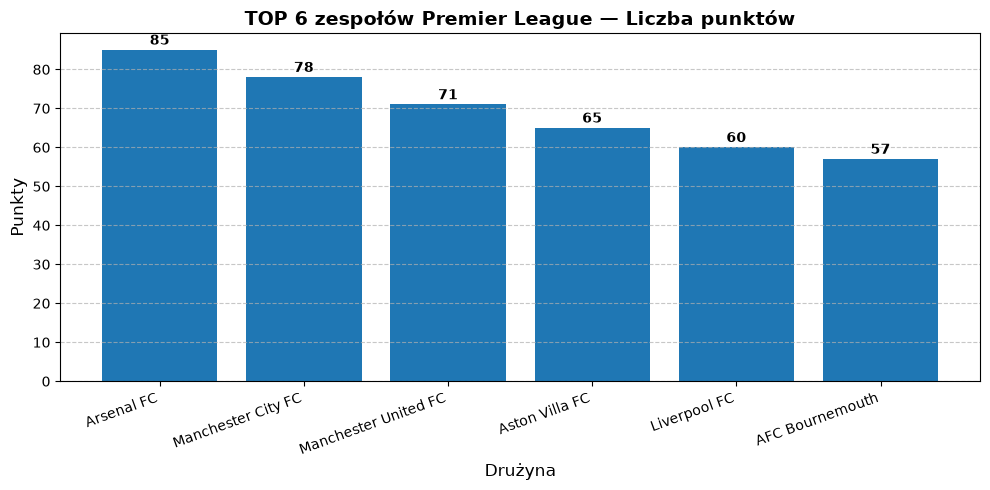

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine

# 1. Połączenie z bazą
load_dotenv()
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_USER = os.getenv("DB_USER", "root")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME", "football_data_db")

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}")

# 2. Pobranie TOP 6 drużyn z tabeli standings
df_top6 = pd.read_sql("SELECT team_name, points, goal_difference FROM standings ORDER BY position ASC LIMIT 6", engine)

# 3. Generowanie wykresu słupkowego
plt.figure(figsize=(10, 5))
bars = plt.bar(df_top6['team_name'], df_top6['points'], color='#1f77b4')

plt.title('TOP 6 zespołów Premier League — Liczba punktów', fontsize=14, fontweight='bold')
plt.xlabel('Drużyna', fontsize=12)
plt.ylabel('Punkty', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Dodanie wartości punktowych nad słupkami
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()